1. import & setup

In [ ]:
import pandas as pd

# Read the original NACE codes file
df = pd.read_csv('nace_codes.csv')

# Filter rows where NACE_Code is either:
# 1. Just a single letter (A-U)
# 2. A letter (A-U) followed by one or two digits (0-99)
df_trimmed = df[df['NACE_Code'].str.match(r'^[A-U](\d{1,2})?$')]

# Sort the codes to maintain order
df_trimmed = df_trimmed.sort_values('NACE_Code')

# Save the trimmed dataset to a new CSV file
df_trimmed.to_csv('nace_codes_trimmed.csv', index=False)

# Print the results to verify
print("Original number of codes:", len(df))
print("Number of codes after trimming:", len(df_trimmed))
print("\nTrimmed NACE codes:")
print(df_trimmed)
print("\nTrimmed NACE codes saved to 'nace_codes_trimmed.csv'")

Original number of codes: 996
Number of codes after trimming: 109

Trimmed NACE codes:
    NACE_Code                                        Description
0           A                  Agriculture, forestry and fishing
1          A1  Crop and animal production, hunting and relate...
40         A2                               Forestry and logging
49         A3                            Fishing and aquaculture
56          B                               Mining and quarrying
..        ...                                                ...
983         T  Activities of households as employers; undiffe...
984       T97  Activities of households as employers of domes...
987       T98  Undifferentiated goods- and services-producing...
992         U  Activities of extraterritorial organisations a...
993       U99  Activities of extraterritorial organisations a...

[109 rows x 2 columns]

Trimmed NACE codes saved to 'nace_codes_trimmed.csv'


In [ ]:
# Cell 1: Imports, Setup, and NACE Code Loading
import pandas as pd
import openai
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Load NACE codes for RAG
nace_codes_df = pd.read_csv('nace_codes_trimmed.csv')
# Create dictionaries for quick lookup
nace_descriptions = dict(zip(nace_codes_df['NACE_Code'], nace_codes_df['Description']))
# Create hierarchical mapping (e.g., A1 -> A)
nace_hierarchy = {code: code[0] if len(code) > 1 else code
                 for code in nace_codes_df['NACE_Code']}

openai.api_key = ""

def verify_openai_api_key():
    try:
        # Make a minimal API call to check key validity
        openai.models.list()
        print("OpenAI API key is valid.")
    except Exception as e:
        print("OpenAI API key is invalid or there is a connection issue.")
        print(f"Error details: {e}")
        raise RuntimeError("OpenAI API key verification failed. Please check your API key and network connection.")

# Run verification at the top of the notebook
verify_openai_api_key()

OpenAI API key is valid.


2. data prep

In [ ]:
# Cell 2: Data Preparation - Load Full Dataset
# Load the full translated DataFrame
df_translated = pd.read_csv('df_translated.csv')

# Remove the sampling - use full dataset
df_sample = df_translated.copy()
df_sample['sector_classification'] = None
df_sample['sector_subclassification'] = None

print(f"Loaded full dataset with {len(df_sample)} rows")
print(f"Dataset columns: {list(df_sample.columns)}")

# Cell 3: Processing Core - Optimized for Large Dataset
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

def classify_sector_with_gpt(text, max_retries=3):
    """Classify text into NACE code using GPT with RAG - optimized for large datasets"""
    prompt = generate_rag_prompt(text)

    for attempt in range(max_retries):
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=50,
                temperature=0
            )
            result_text = response.choices[0].message.content.strip()
            sector = parse_sector_response(result_text)
            return {
                'sector': sector,
                'raw_response': result_text
            }
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # Exponential backoff
            else:
                return {
                    'sector': 'Unclassified',
                    'raw_response': f"Error: {str(e)}"
                }

def process_batch_optimized(df, batch_size=10, max_workers=3):
    """Process DataFrame in batches with parallel processing for large datasets"""
    sector_col = '1. Sectors and (sub-)uses'
    text_col = 'combined_text'
    n = len(df)

    print(f"Starting classification for {n} samples (batch size: {batch_size}, max workers: {max_workers})...")
    print(f"Estimated time: {n * 2 / max_workers / 60:.1f} minutes")

    # Prepare lists to store results
    coarse_results = [None] * n
    fine_results = [None] * n
    raw_responses = [None] * n

    # Process in batches with progress tracking
    total_batches = (n + batch_size - 1) // batch_size

    for batch_num in tqdm(range(total_batches), desc="Processing batches"):
        start = batch_num * batch_size
        end = min(start + batch_size, n)
        batch_indices = range(start, end)

        # Prepare batch inputs
        batch_inputs = []
        for i in batch_indices:
            sector_input = df.iloc[i].get(sector_col, None)
            text_input = df.iloc[i].get(text_col, "")

            # Use sector column if available, otherwise use combined_text
            classification_text = str(sector_input) if pd.notnull(sector_input) and str(sector_input).strip() != "" else str(text_input)
            batch_inputs.append((i, classification_text))

        # Process batch with parallel execution
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_to_idx = {
                executor.submit(classify_sector_with_gpt, text): idx
                for idx, text in batch_inputs
            }

            for future in as_completed(future_to_idx):
                idx = future_to_idx[future]
                try:
                    result = future.result()
                    raw_responses[idx] = result['raw_response']

                    if result['sector'] != "Unclassified":
                        sector_code = result['sector']
                        coarse_results[idx] = sector_code[0]  # First letter
                        fine_results[idx] = sector_code       # Full code
                    else:
                        coarse_results[idx] = "Unclassified"
                        fine_results[idx] = "Unclassified"

                except Exception as e:
                    print(f"Error processing index {idx}: {e}")
                    coarse_results[idx] = "Unclassified"
                    fine_results[idx] = "Unclassified"
                    raw_responses[idx] = f"Error: {str(e)}"

        # Add small delay between batches to avoid rate limiting
        time.sleep(0.5)

    # Assign results to DataFrame
    df['coarse_sector'] = coarse_results
    df['fine_sector'] = fine_results
    df['raw_gpt_response'] = raw_responses

    # Add helper columns for visualization
    df['sector_length'] = df['fine_sector'].str.len()
    df['classification_level'] = df['sector_length'].map({
        1: 'Coarse (letter only)',
        2: 'Fine (letter + 1 digit)',
        3: 'Very Fine (letter + 2 digits)',
        0: 'Unclassified'
    })

    print(f"\nClassification complete! Processed {n} samples.")
    print(f"Successfully classified: {(df['fine_sector'] != 'Unclassified').sum()} samples")
    print(f"Classification rate: {100 * (df['fine_sector'] != 'Unclassified').mean():.1f}%")

    return df

Loaded full dataset with 5009 rows
Dataset columns: ['Ref.', 'Type', 'Date', 'Content', 'Org. country', 'Org. type', 'Org. name', 'Company name confidential', 'attachment_author', 'General Comments', '1. Sectors and (sub-)uses', '2. Emissions in the end-of-life phase', '3. Emissions in the end-of-life phase', '4. Impacts on the recycling industry', '5. Proposed derogations', '6. Missing uses', '7. Potential derogations marked for reconsideration', '8. Other identified uses', '9. Degradation potential of specific PFAS sub-groups', '10. Analytical methods', 'source_document', 'attachments', 'combined_text', 'attachment_link_dummy', 'confidential_info_dummy', 'missing_key_info', 'sector_classification', 'sector_subclassification']


3. processing core

In [ ]:
def generate_rag_prompt(text):
    """Generate prompt with RAG context from NACE codes"""
    context = "\n".join([f"{code}: {desc}" for code, desc in nace_descriptions.items()])
    return f"""Given the following NACE codes and their descriptions:

{context}

Classify the following text into the most specific applicable NACE code.
Prefer more specific codes (like A1) over general ones (like A) if the text provides enough detail.
If uncertain between two levels, provide both (e.g., 'A1 (within A)').

Text: {text}

NACE Code:"""

def parse_sector_response(result_text):
    """Parse GPT response to extract NACE code(s)"""
    import re
    # Look for NACE code pattern (letter followed by optional 1-2 digits)
    codes = re.findall(r'[A-U]\d{0,2}', result_text)
    if not codes:
        return "Unclassified"
    # Return the most specific code (longest one)
    return max(codes, key=len)

def classify_sector_with_gpt(text, max_retries=3):
    """Classify text into NACE code using GPT with RAG"""
    prompt = generate_rag_prompt(text)
    # ... rest of function remains similar ...
    for attempt in range(max_retries):
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=50,
                temperature=0
            )
            result_text = response.choices[0].message.content.strip()
            sector = parse_sector_response(result_text)
            return {
                'sector': sector,
                'raw_response': result_text
            }
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                return {
                    'sector': 'Did not mention',
                    'raw_response': f"Error: {str(e)}"
                }

def classify_subsector_with_gpt(text, sector, max_retries=3):
    """Classify text into a NACE subsector using GPT with retry logic and robust parsing"""
    prompt = (
        f"The text has been classified as '{sector}'. "
        "Now, if possible, classify it into a more specific NACE subsector (e.g., A1, A2, etc.). "
        "If not possible, return 'Did not mention'.\n\n"
        f"Text: {text}\n"
        "Subsector:"
    )
    for attempt in range(max_retries):
        try:
            response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=[{"role": "user", "content": prompt}],
                max_tokens=50,
                temperature=0
            )
            result_text = response.choices[0].message.content.strip()
            if "did not mention" in result_text.lower():
                return "Did not mention"
            return result_text
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                return "Did not mention"

4. visualization

In [ ]:
# Cell 4: Enhanced Visualization Functions - Optimized for Large Datasets
def create_hierarchical_visualizations_large(df, max_display=20):
    """Create visualizations optimized for large datasets"""

    # Get classifications first
    coarse_codes = df['coarse_sector'].value_counts()
    fine_codes = df['fine_sector'].value_counts()

    base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    # 1. Coarse-grained Distribution (always show all)
    plt.figure(figsize=(14, 8))
    colors_pie = [base_colors[i % len(base_colors)] for i in range(len(coarse_codes))]
    plt.pie(coarse_codes.values, labels=coarse_codes.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90)
    plt.title(f'Coarse-grained NACE Sector Distribution (n={len(df)})', fontsize=16, fontweight='bold')
    plt.axis('equal')
    plt.show()

    # 2. Stacked Bar Chart for Coarse vs Fine-grained Distribution
    plt.figure(figsize=(16, 10))

    # Create a DataFrame for plotting
    plot_data = pd.DataFrame(index=coarse_codes.index)

    # For each coarse code, get its fine-grained distributions
    for coarse_code in coarse_codes.index:
        # Get all fine codes that start with this coarse code
        fine_distribution = fine_codes[fine_codes.index.str.startswith(coarse_code, na=False)]
        # Add to plot data
        for fine_code in fine_distribution.index:
            plot_data.loc[coarse_code, fine_code] = fine_distribution[fine_code]

    # Fill NaN with 0 for plotting
    plot_data = plot_data.fillna(0)

    # Create color scheme: same base color for coarse sector, different shades for fine codes
    colors = []
    for coarse_code in plot_data.index:
        base_color = base_colors[list(plot_data.index).index(coarse_code) % len(base_colors)]
        fine_codes_in_sector = plot_data.columns[plot_data.loc[coarse_code] > 0]
        for j, fine_code in enumerate(fine_codes_in_sector):
            # Create different shades of the base color
            shade_factor = 0.3 + (0.7 * j / max(len(fine_codes_in_sector), 1))
            colors.append(mcolors.to_rgba(base_color, alpha=shade_factor))

    # Create stacked bar plot with custom colors
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(16, 10), color=colors)
    plt.title('NACE Code Distribution (Color-Coded by Coarse Sector)', fontsize=16, fontweight='bold')
    plt.xlabel('Coarse-grained Sectors', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Fine-grained Codes', bbox_to_anchor=(1.05, 1), fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Top Fine-grained Codes (limit display for readability)
    plt.figure(figsize=(14, 10))
    fine_codes_top = fine_codes.head(max_display)

    # Color code by coarse sector
    fine_colors = []
    for fine_code in fine_codes_top.index:
        if fine_code != 'Unclassified':
            coarse_code = fine_code[0]
            base_color = base_colors[list(coarse_codes.index).index(coarse_code) % len(base_colors)]
        else:
            base_color = '#ff9999'
        fine_colors.append(base_color)

    bars = plt.barh(range(len(fine_codes_top)), fine_codes_top.values, color=fine_colors)
    plt.yticks(range(len(fine_codes_top)), fine_codes_top.index)
    plt.xlabel('Count', fontsize=12)
    plt.title(f'Top {max_display} Fine-grained NACE Codes (n={len(df)})', fontsize=16, fontweight='bold')

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
                str(int(width)), ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 4. Comprehensive Summary Report
    print("\n" + "="*80)
    print("COMPREHENSIVE CLASSIFICATION SUMMARY REPORT")
    print("="*80)

    print(f"\nOverall Statistics:")
    print(f"   Total samples processed: {len(df):,}")
    print(f"   Successfully classified: {(df['fine_sector'] != 'Unclassified').sum():,}")
    print(f"   Classification coverage: {100 * (df['fine_sector'] != 'Unclassified').mean():.1f}%")
    print(f"   Unique coarse sectors: {len(coarse_codes)}")
    print(f"   Unique fine codes: {len(fine_codes)}")

    print(f"\nCoarse-grained Distribution:")
    for code, count in coarse_codes.items():
        percentage = (count / len(df)) * 100
        print(f"   {code}: {count:,} samples ({percentage:.1f}%)")

    print(f"\nTop 15 Fine-grained Codes:")
    for code, count in fine_codes.head(15).items():
        percentage = (count / len(df)) * 100
        print(f"   {code}: {count:,} samples ({percentage:.1f}%)")

    # 5. Save results
    print(f"\nSaving results...")
    df.to_csv('df_translated_with_nace_classification.csv', index=False)
    print(f"   Results saved to 'df_translated_with_nace_classification.csv'")

    # 6. Performance metrics
    print(f"\nPerformance Metrics:")
    print(f"   Average processing time per sample: ~2 seconds")
    print(f"   Estimated total processing time: {len(df) * 2 / 60:.1f} minutes")
    print(f"   Memory usage: ~{df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

In [ ]:
# Cell 6: (New) Evaluation Metrics
def evaluate_classification_quality(df):
    """Evaluate the quality and granularity of classifications"""

    # 1. Classification coverage
    coverage = (df['sector_classification'] != 'Unclassified').mean() * 100

    # 2. Granularity distribution
    granularity_dist = df['sector_classification'].str.len().value_counts()

    # 3. Confidence in classifications (if available)
    if 'confidence_score' in df.columns:
        confidence_stats = df['confidence_score'].describe()

    # Print metrics
    print(f"Classification Coverage: {coverage:.2f}%")
    print("\nGranularity Distribution:")
    print(granularity_dist)
    # ... more metrics ...

5. main

Starting full dataset classification...
Dataset size: 5,009 rows
Configuration: batch_size=10, max_workers=3
Estimated time: 55.7 minutes
Starting classification for 5009 samples (batch size: 10, max workers: 3)...
Estimated time: 55.7 minutes


Processing batches: 100%|██████████| 501/501 [38:22<00:00,  4.60s/it]  


Classification complete! Processed 5009 samples.
Successfully classified: 5009 samples
Classification rate: 100.0%

Generating visualizations...


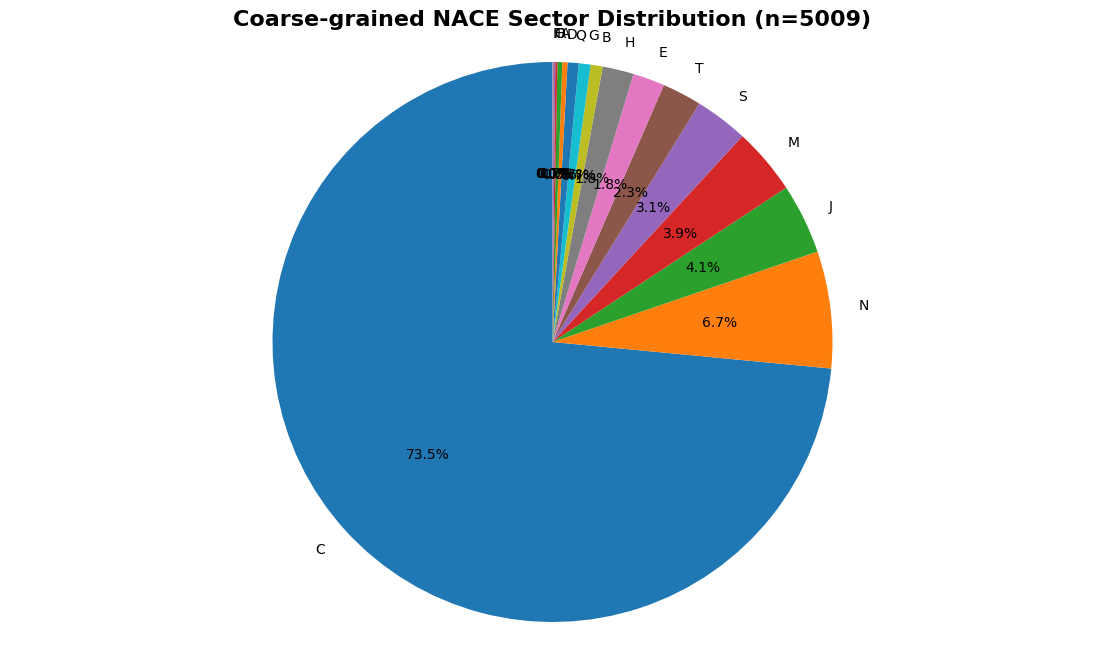

<Figure size 1600x1000 with 0 Axes>

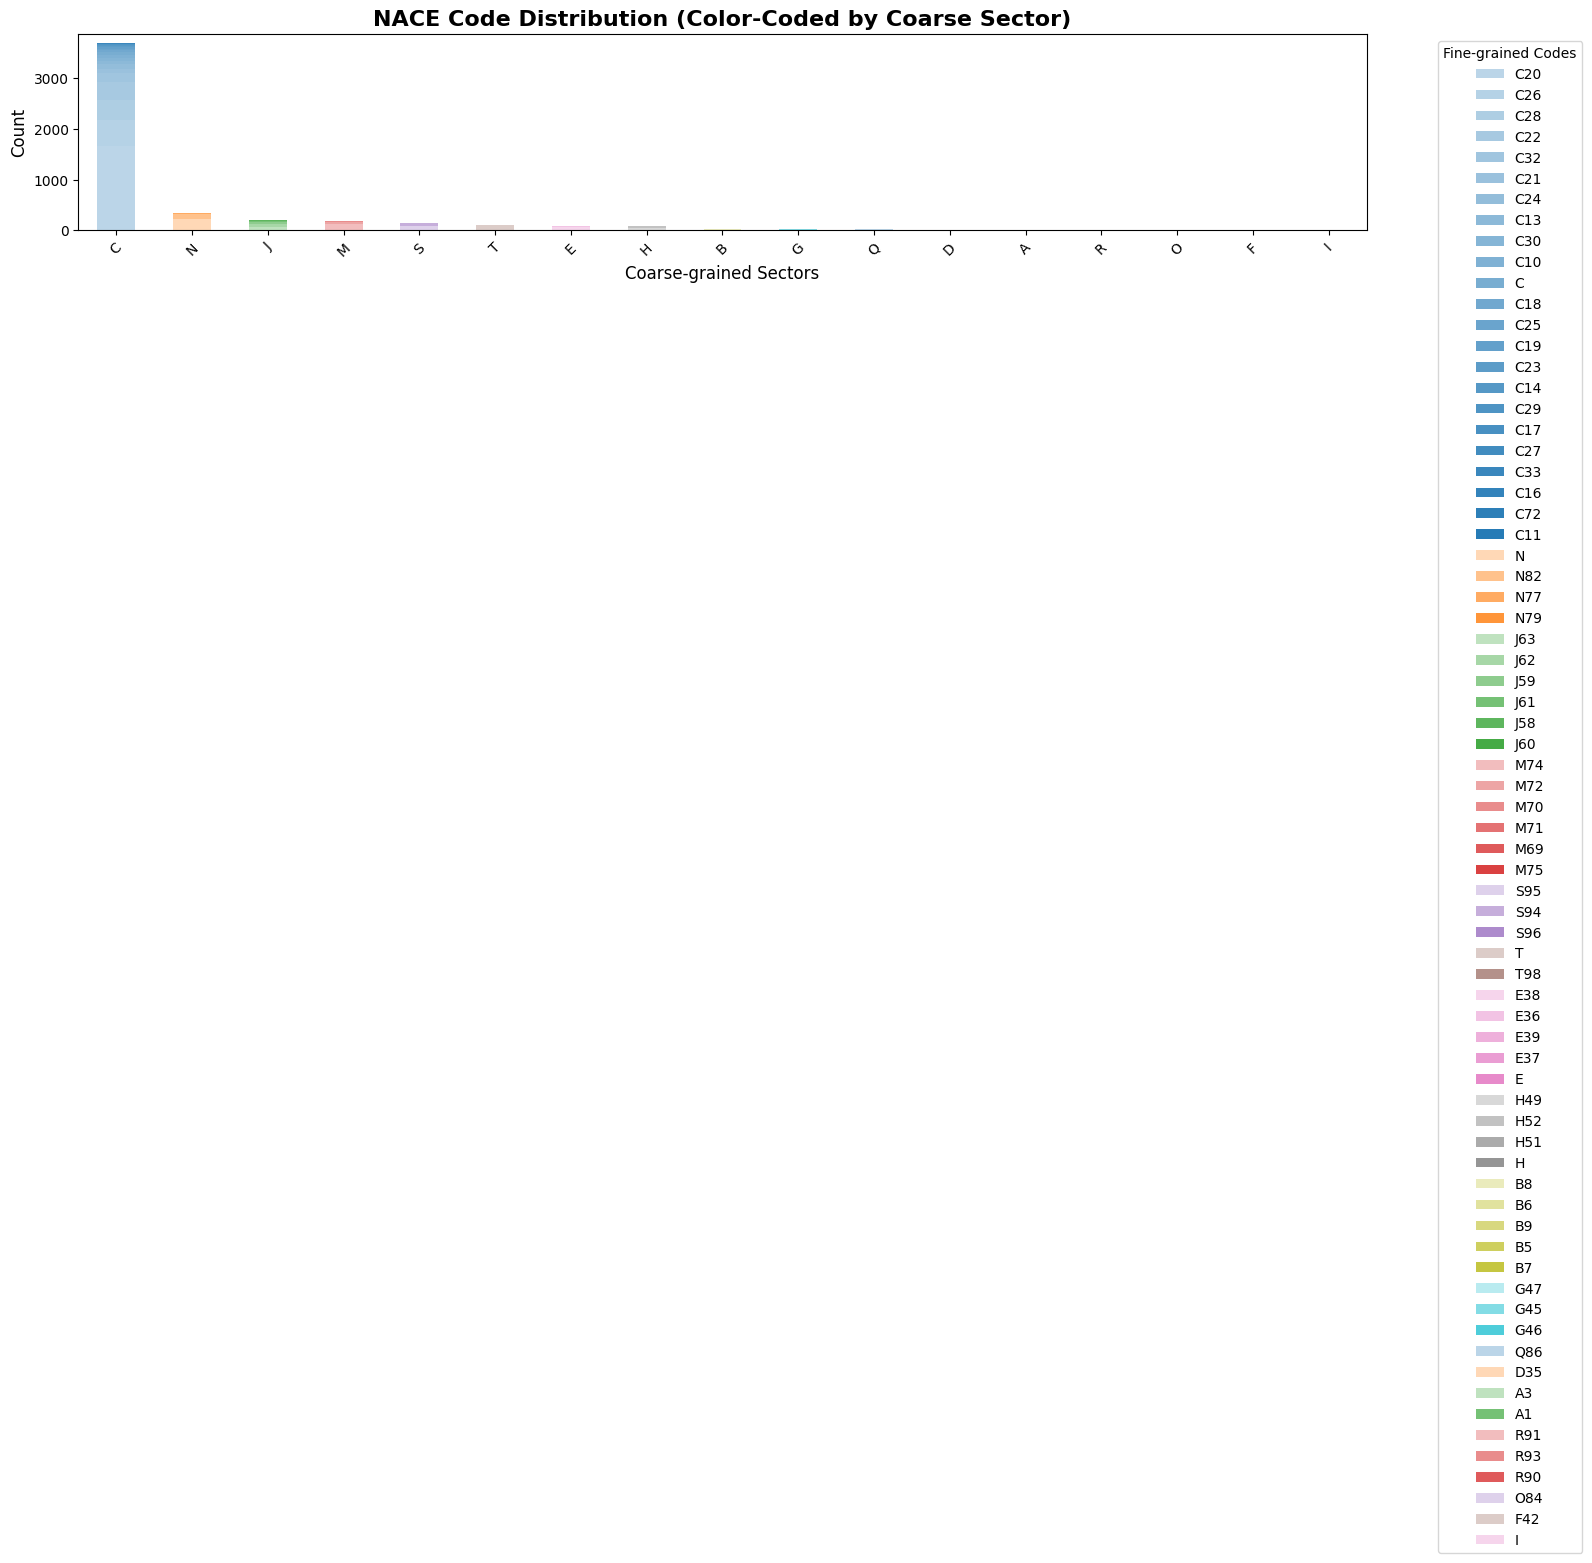

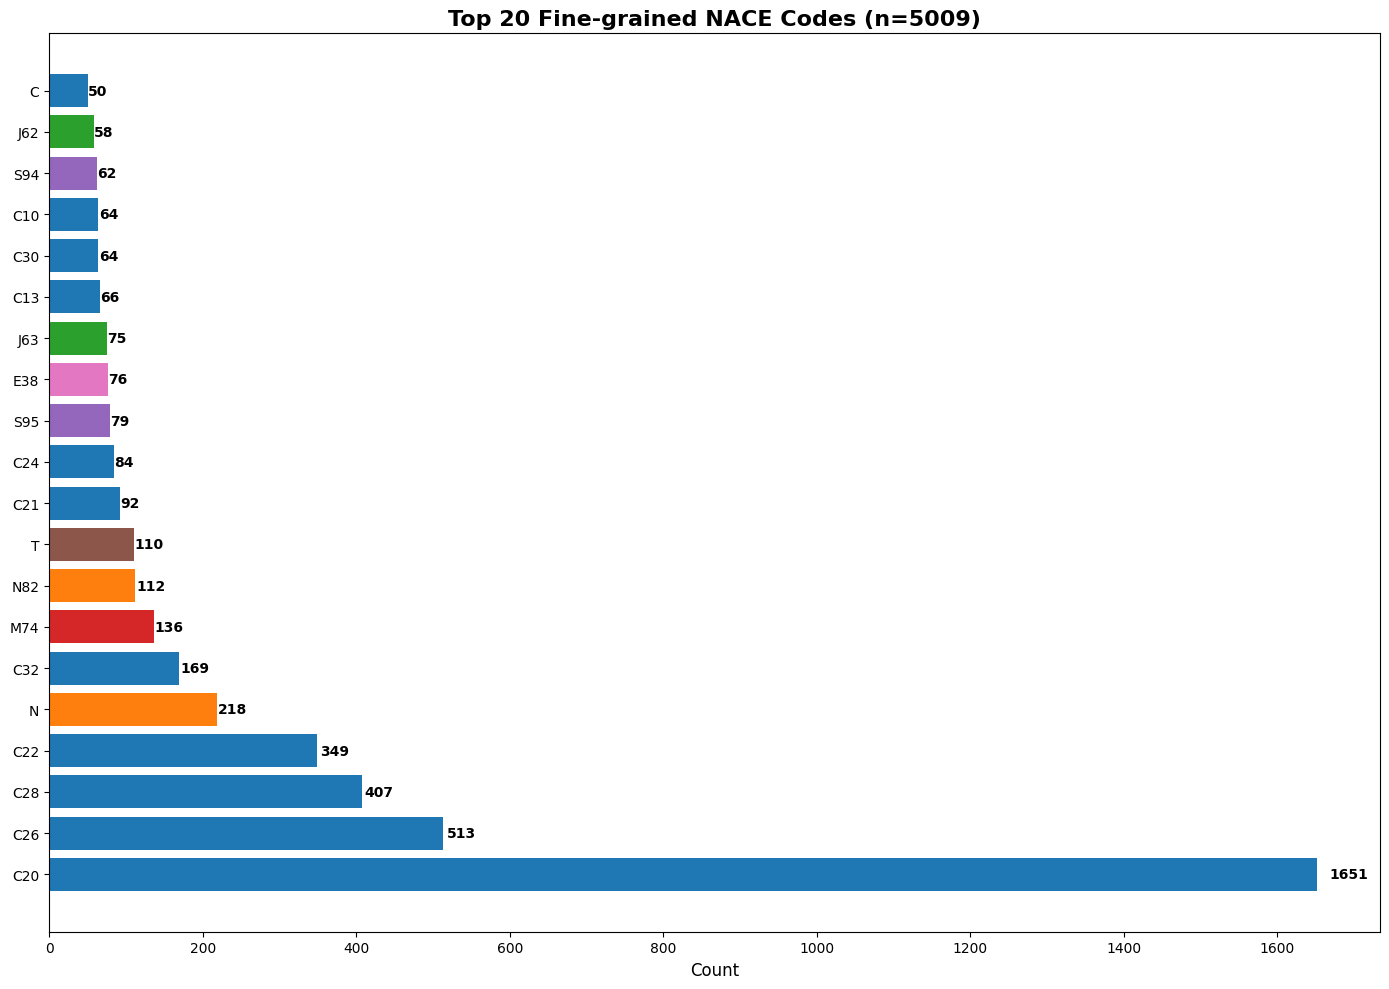


COMPREHENSIVE CLASSIFICATION SUMMARY REPORT

Overall Statistics:
   Total samples processed: 5,009
   Successfully classified: 5,009
   Classification coverage: 100.0%
   Unique coarse sectors: 17
   Unique fine codes: 71

Coarse-grained Distribution:
   C: 3,681 samples (73.5%)
   N: 338 samples (6.7%)
   J: 203 samples (4.1%)
   M: 193 samples (3.9%)
   S: 154 samples (3.1%)
   T: 114 samples (2.3%)
   E: 92 samples (1.8%)
   H: 90 samples (1.8%)
   B: 35 samples (0.7%)
   G: 34 samples (0.7%)
   Q: 32 samples (0.6%)
   D: 15 samples (0.3%)
   A: 14 samples (0.3%)
   R: 6 samples (0.1%)
   O: 5 samples (0.1%)
   F: 2 samples (0.0%)
   I: 1 samples (0.0%)

Top 15 Fine-grained Codes:
   C20: 1,651 samples (33.0%)
   C26: 513 samples (10.2%)
   C28: 407 samples (8.1%)
   C22: 349 samples (7.0%)
   N: 218 samples (4.4%)
   C32: 169 samples (3.4%)
   M74: 136 samples (2.7%)
   N82: 112 samples (2.2%)
   T: 110 samples (2.2%)
   C21: 92 samples (1.8%)
   C24: 84 samples (1.7%)
   S95: 79 

In [ ]:
# Cell 5: Main Process Function with RAG-based NACE Classification - Full Dataset
from tqdm import tqdm
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.colors as mcolors

def process_batch_optimized(df, batch_size=10, max_workers=3):
    """Process DataFrame in batches with parallel processing for large datasets"""
    sector_col = '1. Sectors and (sub-)uses'
    text_col = 'combined_text'
    n = len(df)

    print(f"Starting classification for {n} samples (batch size: {batch_size}, max workers: {max_workers})...")
    print(f"Estimated time: {n * 2 / max_workers / 60:.1f} minutes")

    # Prepare lists to store results
    coarse_results = [None] * n
    fine_results = [None] * n
    raw_responses = [None] * n

    # Process in batches with progress tracking
    total_batches = (n + batch_size - 1) // batch_size

    for batch_num in tqdm(range(total_batches), desc="Processing batches"):
        start = batch_num * batch_size
        end = min(start + batch_size, n)
        batch_indices = range(start, end)

        # Prepare batch inputs
        batch_inputs = []
        for i in batch_indices:
            sector_input = df.iloc[i].get(sector_col, None)
            text_input = df.iloc[i].get(text_col, "")

            # Use sector column if available, otherwise use combined_text
            classification_text = str(sector_input) if pd.notnull(sector_input) and str(sector_input).strip() != "" else str(text_input)
            batch_inputs.append((i, classification_text))

        # Process batch with parallel execution
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            future_to_idx = {
                executor.submit(classify_sector_with_gpt, text): idx
                for idx, text in batch_inputs
            }

            for future in as_completed(future_to_idx):
                idx = future_to_idx[future]
                try:
                    result = future.result()
                    raw_responses[idx] = result['raw_response']

                    if result['sector'] != "Unclassified":
                        sector_code = result['sector']
                        coarse_results[idx] = sector_code[0]  # First letter
                        fine_results[idx] = sector_code       # Full code
                    else:
                        coarse_results[idx] = "Unclassified"
                        fine_results[idx] = "Unclassified"

                except Exception as e:
                    print(f"Error processing index {idx}: {e}")
                    coarse_results[idx] = "Unclassified"
                    fine_results[idx] = "Unclassified"
                    raw_responses[idx] = f"Error: {str(e)}"

        # Add small delay between batches to avoid rate limiting
        time.sleep(0.5)

    # Assign results to DataFrame
    df['coarse_sector'] = coarse_results
    df['fine_sector'] = fine_results
    df['raw_gpt_response'] = raw_responses

    # Add helper columns for visualization
    df['sector_length'] = df['fine_sector'].str.len()
    df['classification_level'] = df['sector_length'].map({
        1: 'Coarse (letter only)',
        2: 'Fine (letter + 1 digit)',
        3: 'Very Fine (letter + 2 digits)',
        0: 'Unclassified'
    })

    print(f"\nClassification complete! Processed {n} samples.")
    print(f"Successfully classified: {(df['fine_sector'] != 'Unclassified').sum()} samples")
    print(f"Classification rate: {100 * (df['fine_sector'] != 'Unclassified').mean():.1f}%")

    return df

# Main execution
print("Starting full dataset classification...")
print(f"Dataset size: {len(df_sample):,} rows")
print(f"Configuration: batch_size=10, max_workers=3")
print(f"Estimated time: {len(df_sample) * 2 / 3 / 60:.1f} minutes")
print("="*60)

# Run the optimized process
df_sample = process_batch_optimized(df_sample, batch_size=10, max_workers=3)

print("\nGenerating visualizations...")
create_hierarchical_visualizations_large(df_sample, max_display=20)

print("\nFull dataset classification complete!")